In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# --- Step 1: Data Loading ---
(x_train, _), (x_test, _) = mnist.load_data()
x_train_norm = np.expand_dims(x_train.astype('float32') / 255., axis=-1)
x_test_norm = np.expand_dims(x_test.astype('float32') / 255., axis=-1)

In [13]:
# --- Step 2: Create Noisy Data ---
noise_factor = 0.4
x_train_noisy = x_train_norm + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train_norm.shape)
x_test_noisy = x_test_norm + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_norm.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [14]:
# --- Step 3: Defining the Denoising Autoencoder (with ReLU) ---
print("\n--- Defining the Denoising Autoencoder Model ---")
latent_dim = 2

# Encoder
input_img = Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2)(input_img)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=2)(x)
x = layers.Flatten()(x)
encoded = layers.Dense(latent_dim, name="latent_space", activation='relu')(x)

# Decoder
x_dec = layers.Dense(7 * 7 * 64, activation='relu')(encoded)
x_dec = layers.Reshape((7, 7, 64))(x_dec)
x_dec = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2)(x_dec)
x_dec = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2)(x_dec)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x_dec)

autoencoder = Model(input_img, decoded, name="denoising_autoencoder_relu")
autoencoder.summary()



--- Defining the Denoising Autoencoder Model ---
Model: "denoising_autoencoder_relu"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 32)        320       
                                                                 
 conv2d_4 (Conv2D)           (None, 7, 7, 64)          18496     
                                                                 
 flatten_1 (Flatten)         (None, 3136)              0         
                                                                 
 latent_space (Dense)        (None, 2)                 6274      
                                                                 
 dense_1 (Dense)             (None, 3136)              9408      
                                                        

Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
# --- Step 4: Training the Model (This will now use the GPU) ---
print("\n--- Training the Denoising Autoencoder ---")
optimizer = tf.keras.optimizers.Adam(jit_compile=False)
autoencoder.compile(optimizer=optimizer, loss='binary_crossentropy')
autoencoder.fit(
    x_train_noisy, x_train_norm,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_norm)
)


--- Training the Denoising Autoencoder ---
Epoch 1/20
469/469 [==============================] - 3s 5ms/step - loss: 0.2667 - val_loss: 0.2263
Epoch 2/20
469/469 [==============================] - 2s 5ms/step - loss: 0.2197 - val_loss: 0.2157
Epoch 3/20
469/469 [==============================] - 2s 5ms/step - loss: 0.2128 - val_loss: 0.2101
Epoch 4/20
469/469 [==============================] - 2s 5ms/step - loss: 0.2089 - val_loss: 0.2077
Epoch 5/20
469/469 [==============================] - 2s 5ms/step - loss: 0.2061 - val_loss: 0.2057
Epoch 6/20
469/469 [==============================] - 2s 5ms/step - loss: 0.2039 - val_loss: 0.2027
Epoch 7/20
469/469 [==============================] - 2s 5ms/step - loss: 0.2022 - val_loss: 0.2022
Epoch 8/20
469/469 [==============================] - 2s 5ms/step - loss: 0.2011 - val_loss: 0.2011
Epoch 9/20
469/469 [==============================] - 2s 5ms/step - loss: 0.2002 - val_loss: 0.2008
Epoch 10/20
469/469 [==============================] - 2

In [16]:
print("\n--- Step 5: Generating Images from the Denoising Decoder ---")
num_images_to_generate = 5
mean = 5.0
variance = 1.0
std_dev = np.sqrt(variance) 

decoder_input = Input(shape=(latent_dim,), name="decoder_input")
# Start the chain of layers from our new input
decoder_layers_chain = decoder_input
# Loop through the layers of the trained autoencoder, starting from the first layer of the decoder
for i in range(5, len(autoencoder.layers)):
    decoder_layers_chain = autoencoder.layers[i](decoder_layers_chain)

decoder_model = Model(decoder_input, decoder_layers_chain, name="decoder")

random_latent_vectors = np.random.normal(loc=mean, scale=std_dev, size=(num_images_to_generate, latent_dim))
generated_images = decoder_model.predict(random_latent_vectors)


--- Step 5: Generating Images from the Denoising Decoder ---
1/1 [==============================] - 0s 48ms/step



Displaying generated images...


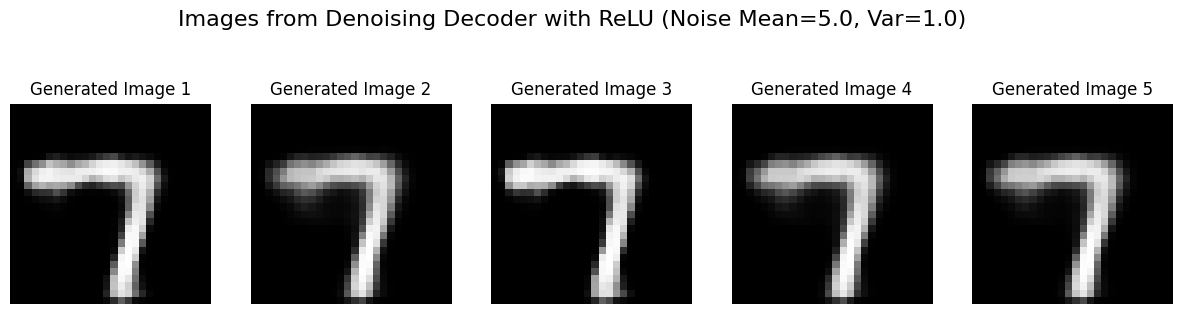

In [17]:
# --- Visualize the Results ---
print("\nDisplaying generated images...")
plt.figure(figsize=(15, 4))
for i in range(num_images_to_generate):
    ax = plt.subplot(1, num_images_to_generate, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Generated Image {i+1}")
    plt.axis("off")
plt.suptitle(f"Images from Denoising Decoder with ReLU (Noise Mean={mean}, Var={variance})", fontsize=16)
plt.show()